# Model Comparison

## Models
All models include temporal weighting to ensure more recent fixtures have a larger effect on the posterior.
The models are:
 - `PoissonModel`
    - Tries and penalties modelled separetly as Poisson processes. Poisson lambda is calculated at exponential of a linear combination of: 
        - attack parameter of team minus fefense parameter of opposition (learned at team level)
            - Zero-sum normmal prior on attack and defense parameters, with half normal hyper-parameter for the standard devation of these distributions. 
        -  Home-team advantage
            - Normal prior
        -  interecpt
            -Normal prior with mean set to the log mean number of tries/penatlies in the dataset. 
    - Conversions are modelled as Binomial distribution with a beta prior at the team level, with mu set to the average conversion rate.

- `PoissonModel_DG`
    - As `PoissonModel` but also models drop goals as Zero-inflated Poisson (with psi parameter (on logit scale) modelling probability of being range of drop-goal and lambda modelled with attacking parameter, intercept and home advantage). Not too familiar with this so a bit experimental.
- `PoissonModel_latAtt`
    - As `PoissonModel` but with a latent attack parameter (normal prior) at the game level, accountring for more open higher scoring games.
- `NegBinModel`
    - As `PoissonModel` but tries and penlties modelled as negative binomial ot account for potential overdispersion. Exponential prior on overdispersion parameter.
- `KISS`
    - Keep it simple stupid. Modelled score on its own as negative binomial (att, def, home and int parameters used for lambda and overdispersion modeeled as in `NegBinModel`). Note that this cannot be used for tournament siumulation as bonus points cannot be modelled without try count.
- `KISSS`
    - Keep is simpler stupid. As `KISS` but with a single strenght parameter per team combining defense and attack parameters, and no home advantage.


Note that here I test modells trained up to a certain date on all future fixtures of focal teams. Ideally the model would be refit on each result up to the fixture being predicted but this would be too slow here. Therefore tests are simulating each fixture based on a teams predicted form at the cutoff. 

## Setup

In [1]:
from rugbyModels import *
np.random.seed(1)
import warnings
warnings.filterwarnings("ignore")

data= pd.read_csv("final_data_1.csv")
data["date"] = pd.to_datetime(data["date"])

dataDGs = data.copy() #save this for the model with separate drop goals

#think its reasoable to combine these for models without dgs - shouldnt overwrite like this but made the descxision too late
data["home_penalties"] = data["home_penalties"]+data["home_drop_goals"] 
data["away_penalties"] = data["away_penalties"]+data["away_drop_goals"]

#train-test split
cutoff = "2025-01-01"
dfTest =  data[data["date"] >= cutoff]
dfTrain = data[data["date"] < cutoff]

dataDGsTest = dataDGs[dataDGs["date"] >= cutoff]
dataDGsTrain = dataDGs[dataDGs["date"] < cutoff]


----
## PoissonModel

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [home, sd_att, sd_def, att, def_, int_try, sd_dis_clean, sd_dis_force, dis_clean, dis_force, int_pen, p_conv]


Output()

Sampling 4 chains for 1_500 tune and 2_500 draw iterations (6_000 + 10_000 draws total) took 70 seconds.


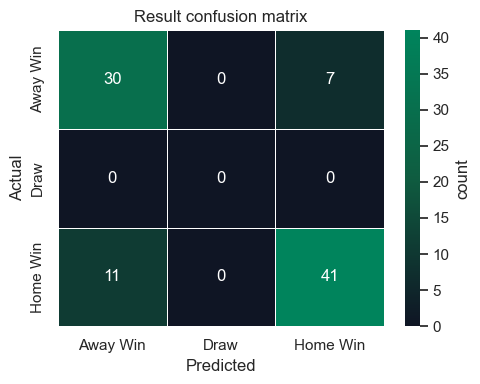

Match result accuracy = 0.797752808988764


Score level evaulation:

    Number of usable tests: 89

    Average observed score = 27.617977528089888 per team per game.
    Average predicted score = 27.144483707865174 per team per game.
    MAE score = 13.057494943820226 per team per game.
    MAE score difference = 14.334141573033707


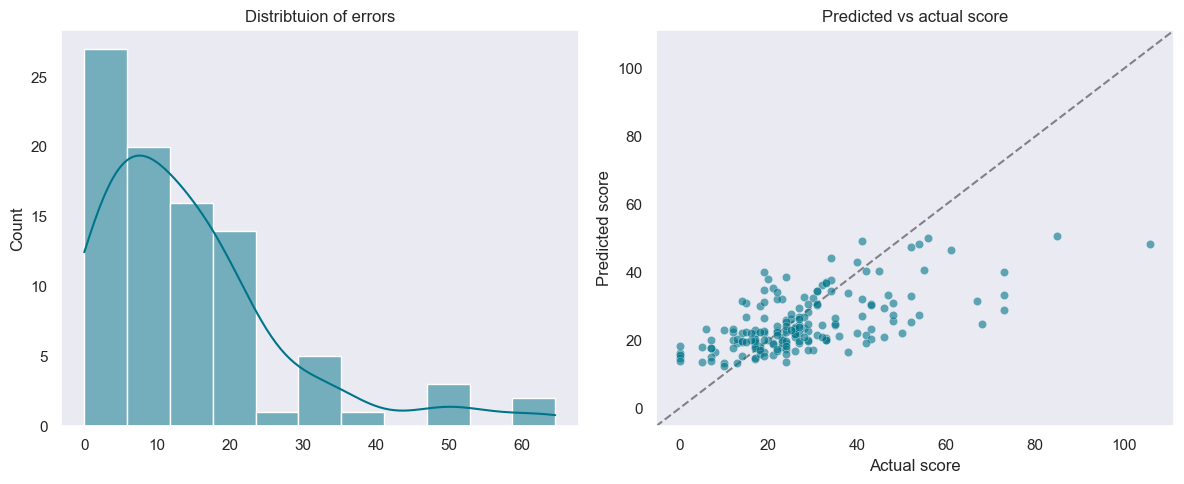

In [2]:
poisson = PoissonModel()
poissonFit = poisson.fit(dfTrain)
_ = poissonFit.eval_result(dfTest)
_ = poissonFit.eval_score(dfTest)

----
## NegBinModel
Not unreasonable that try and penalty counts would be overdispersed.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [home, sd_att, sd_def, att, def_, int_try, alpha, sd_dis_clean, sd_dis_force, alphaPen, dis_clean, dis_force, int_pen, p_conv]


Output()

Sampling 4 chains for 1_500 tune and 2_500 draw iterations (6_000 + 10_000 draws total) took 146 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


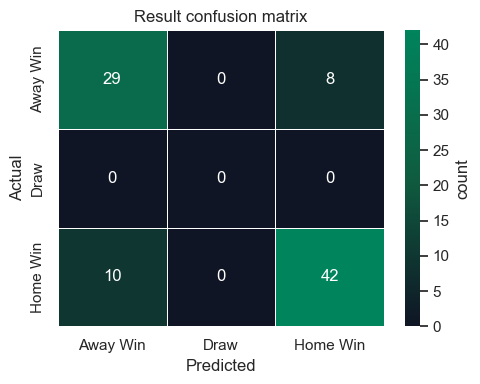

Match result accuracy = 0.797752808988764


Score level evaulation:

    Number of usable tests: 89

    Average observed score = 27.617977528089888 per team per game.
    Average predicted score = 27.13884775280899 per team per game.
    MAE score = 13.075128651685395 per team per game.
    MAE score difference = 14.346177528089887


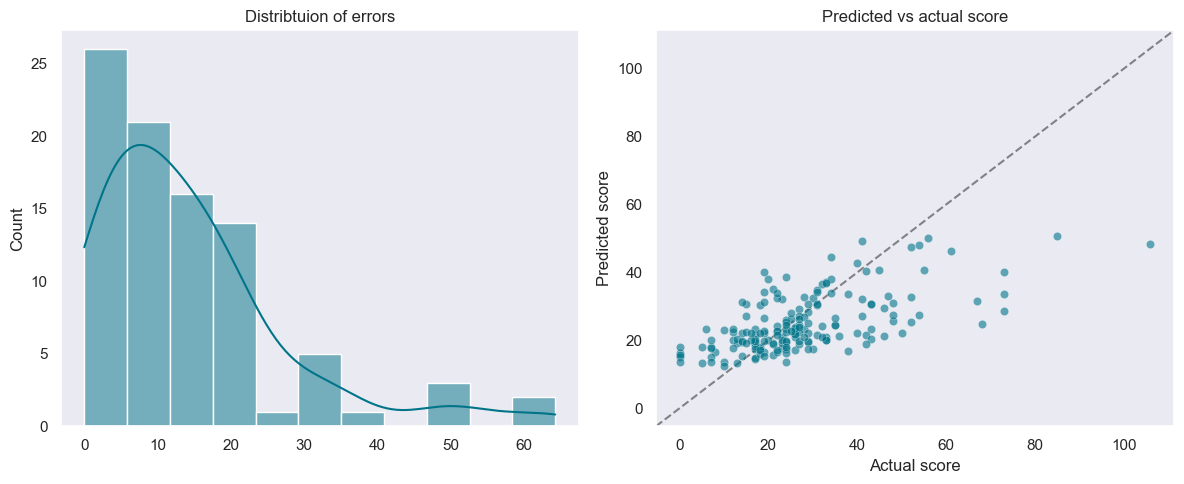

14.346177528089887

In [3]:
nb = NegBinModel()
nbFit = nb.fit(dfTrain)
nbFit.eval_result(dfTest)
poissonFit.eval_score(dfTest)

Seems to be slightly worse.

----
## PoissonModel_latAtt
Can a match openness parameter imporve score predictions?

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [home, sd_att, sd_def, att, def_, int_try, sigma_game, game_effect, sd_dis_clean, sd_dis_force, dis_clean, dis_force, int_pen, p_conv]


Output()

Sampling 4 chains for 1_500 tune and 2_500 draw iterations (6_000 + 10_000 draws total) took 103 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


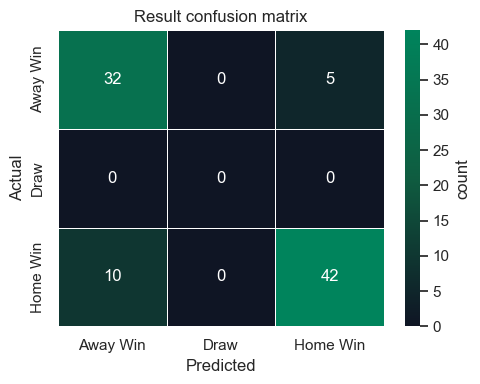

Match result accuracy = 0.8314606741573034


Score level evaulation:

    Number of usable tests: 89

    Average observed score = 27.617977528089888 per team per game.
    Average predicted score = 27.147088202247176 per team per game.
    MAE score = 13.04024382022472 per team per game.
    MAE score difference = 14.314459550561796


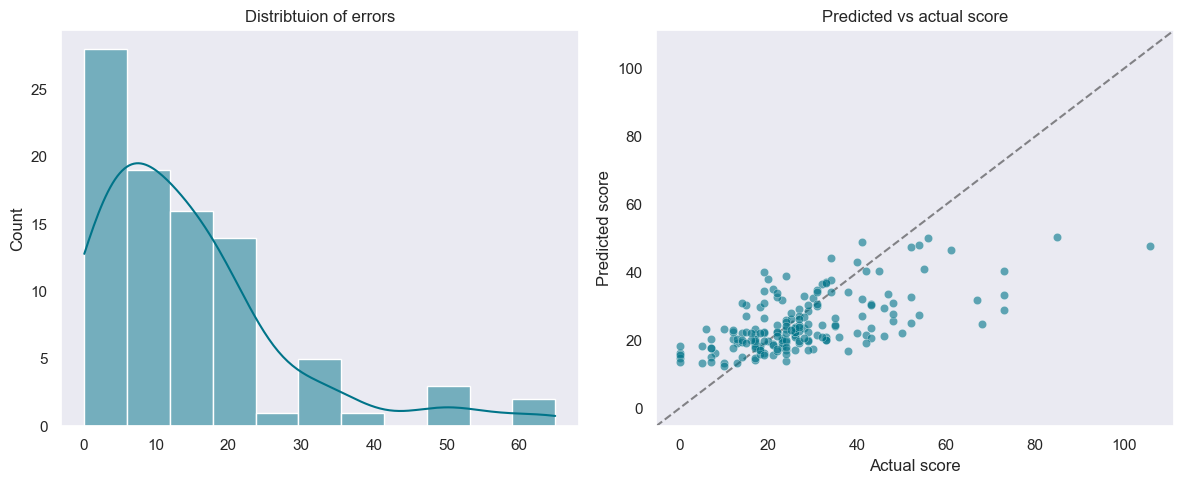

In [4]:
poissonLA = PoissonModel_latAtt()
poissonLAFit = poissonLA.fit(dfTrain)
_ = poissonLAFit.eval_result(dfTest)
_ = poissonLAFit.eval_score(dfTest)

----
## PoissonModel_DG

What if we add drop goals?

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [home, sd_att, sd_def, att, def_, int_try, sd_dis_clean, sd_dis_force, dis_clean, dis_force, int_pen, p_conv, sd_att_dg, att_dg, int_dg, psi_logit_dg]


Output()

Sampling 4 chains for 1_500 tune and 2_500 draw iterations (6_000 + 10_000 draws total) took 119 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


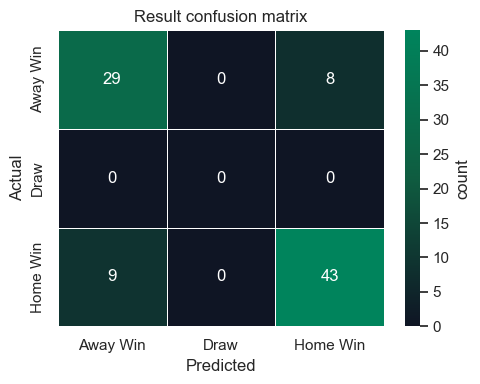

Match result accuracy = 0.8089887640449438


Score level evaulation:

    Number of usable tests: 89

    Average observed score = 27.617977528089888 per team per game.
    Average predicted score = 32.89248595505617 per team per game.
    MAE score = 22.279653932584267 per team per game.
    MAE score difference = 24.63291797752809


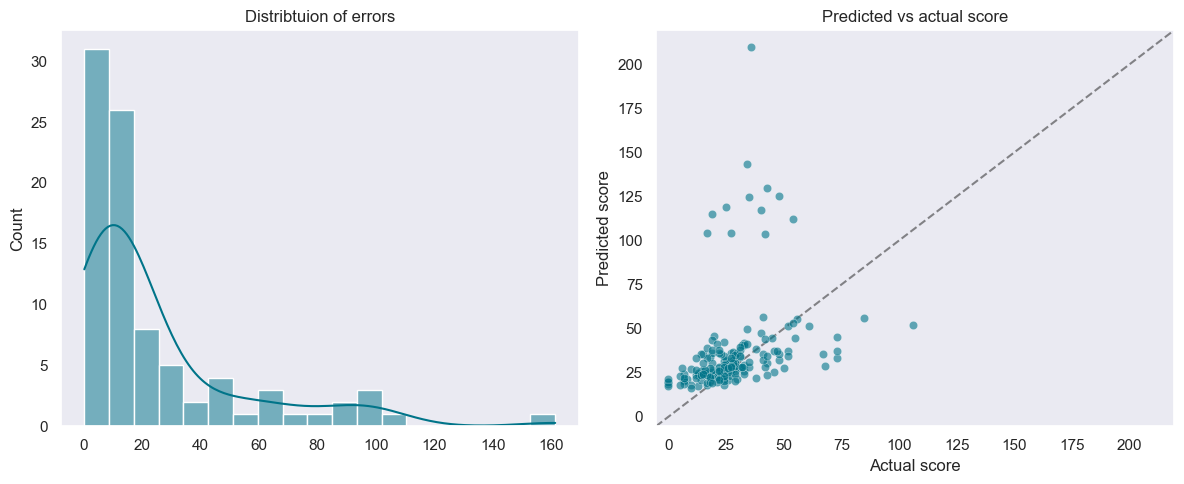

In [5]:
poissonDG = PoissonModel_DG()
poissonDGFit = poissonDG.fit(dfTrain)
_ = poissonDGFit.eval_result(dfTest)
_ = poissonDGFit.eval_score(dfTest)

Not much better, and we dont need DGs to simulate the tournement.

----
## KISS

Out of interest, is a simpler model more accurate?

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [home, sd_att, sd_def, att, def_, int, alpha]


Output()

Sampling 4 chains for 1_500 tune and 2_500 draw iterations (6_000 + 10_000 draws total) took 73 seconds.


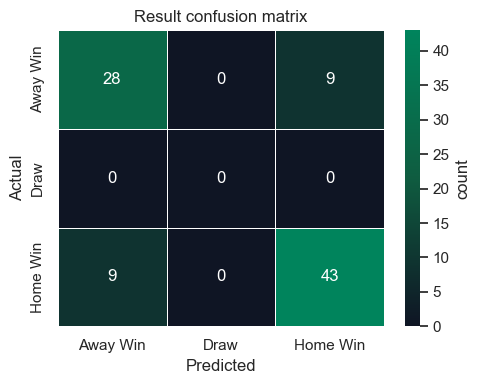

Match result accuracy = 0.797752808988764


Score level evaulation:

    Number of usable tests: 89

    Average observed score = 27.617977528089888 per team per game.
    Average predicted score = 27.590262921348312 per team per game.
    MAE score = 12.945934831460674 per team per game.
    MAE score difference = 14.397370786516854


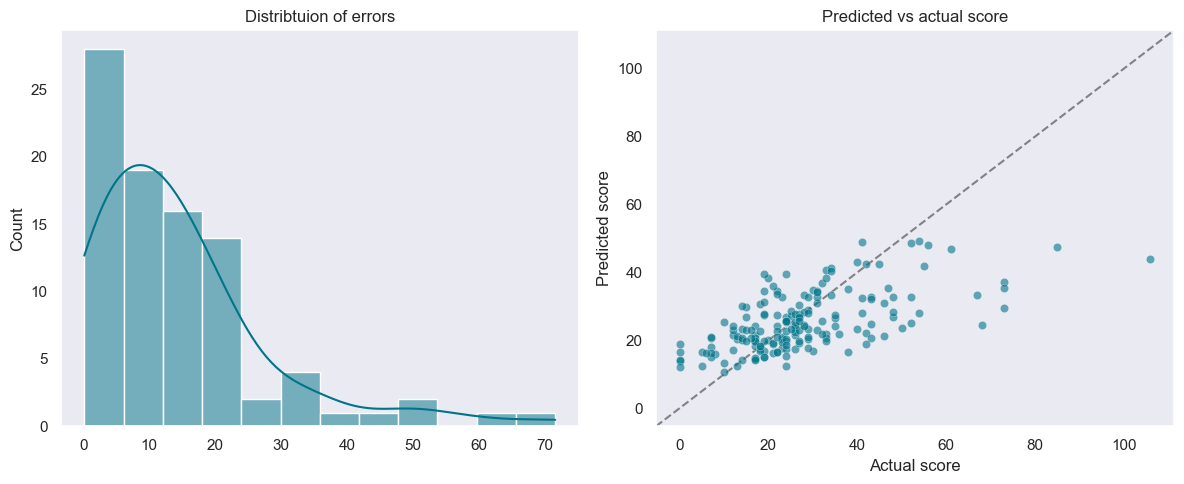

In [6]:
kiss = KISSModel()
kissFit = kiss.fit(dfTrain)
_ = kissFit.eval_result(dfTest)
_ = kissFit.eval_score(dfTest)

----
## KISSS

The simpilest possible model.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sd_strength, strength, int, alpha]


Output()

Sampling 4 chains for 1_500 tune and 2_500 draw iterations (6_000 + 10_000 draws total) took 55 seconds.


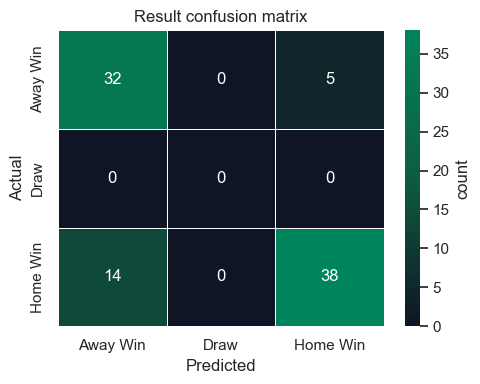

Match result accuracy = 0.7865168539325843


Score level evaulation:

    Number of usable tests: 89

    Average observed score = 27.617977528089888 per team per game.
    Average predicted score = 26.78952247191012 per team per game.
    MAE score = 12.851926404494382 per team per game.
    MAE score difference = 14.28740561797753


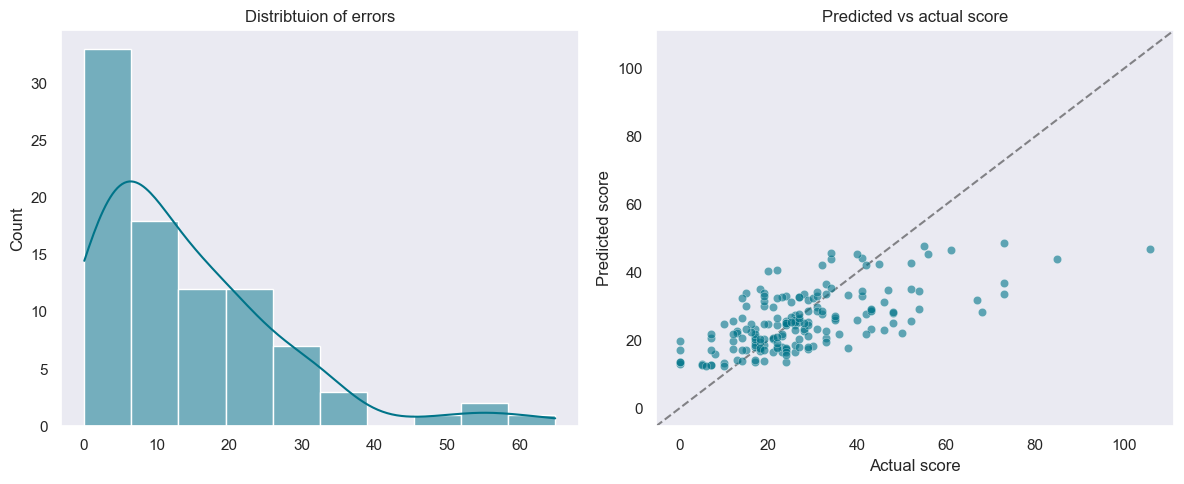

In [7]:
kisss = KISSSModel()
kisssFit = kisss.fit(dfTrain)
_ = kisssFit.eval_result(dfTest)
_ = kisssFit.eval_score(dfTest)

After all that, seems that the original model was best. The joys of machine learning. 